# Phantom Fairness: the fairness illusion created by label noise

### Part 3 of 3 - Cross-continental transfer, a causal noise-injection experiment, the remedy, and the manuscript

This final part turns the descriptive result of Part 2 into a causal one and then into a fix. It contains four pillars.

1. **Cross-continental transfer.** The NIH-trained heads are applied zero-shot to PadChest (Spain; Bustos et al., 2020), where the labels are manually assigned by a different team on a different population. This tests whether the apparent fairness travels or collapses when the label-generating process changes continent.
2. **A causal noise-injection experiment.** This is the heart of the paper. We take the clean adjudicated NIH labels, inject the exact group-dependent flip rates measured in Part 2 using a Wang et al. (2021) class-conditional noise model, and watch phantom fairness reappear on demand. A dose-response sweep and an analytical overlay turn a correlation into a controlled mechanism.
3. **The remedy and its precondition.** Subgroup-specific decision thresholds (equal-opportunity post-processing; Hardt, Price, and Srebro, 2016) close the gap, but only when calibrated on clean labels. We show that the same procedure calibrated on noisy labels fails, which is the operational punchline: you cannot repair a disparity you cannot see, so a clean audit set is not optional.
4. **A robustness battery and the manuscript.** Sensitivity across noise level, subgroup definition, finding, and backbone, followed by a Results and Discussion written for an elite venue.

Injecting bias to validate a fairness claim that would otherwise be merely assumed is now an accepted auditing methodology (provenance-based fairness simulation, 2026), and the accuracy-fairness trade-off we quantify in the remedy is a documented constraint in clinical AI rather than a surprise.

> Run Parts 1 and 2 at least once so the caches exist. Section 0 rehydrates everything from those caches, including the two data fixes from Part 2 folded in, so this notebook also starts clean on a fresh kernel.

---
## 0. Rehydrate Parts 1 and 2

This section reconstructs the configuration, the master frames, the cohort, the cached embeddings, the trained heads, the scored evaluation frame, and the measured group-dependent noise. Two fixes from Part 2 are built in from the start: the adjudicated NIH labels are auto-discovered from the installed TorchXRayVision package if they are not already beside the images, and PadChest is slimmed to parquet-safe columns before caching. Nothing heavy recomputes because the embeddings are cached.

In [21]:
import os, re, json, time, hashlib, logging, warnings, importlib, shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from numpy.random import default_rng
warnings.filterwarnings("ignore")

@dataclass
class Config:
    nih_root: str = r"C:\Users\kruta\Downloads\NIH Chest X-rays"
    padchest_root: str = r"C:\Users\kruta\Downloads\PadChest Chest X-rays (sample)"
    nih_labels_name: str = "Data_Entry_2017.csv"
    nih_google_name: str = "google2019_nih-chest-xray-labels.csv.gz"
    padchest_labels_name: str = "chest_x_ray_images_labels_sample.csv"
    padchest_image_subdir: str = "sample"
    project_dir: str = str(Path.cwd() / "phantom_fairness")
    canonical_findings: Tuple[str, ...] = ("Airspace opacity","Pneumothorax","Nodule or mass","Fracture")
    age_bands: Tuple[Tuple[str,float,float], ...] = (("<40",0.0,40.0),("40-60",40.0,60.0),(">60",60.0,200.0))
    elderly_age_threshold: float = 60.0
    embedding_backbones: Tuple[str, ...] = ("xrv_densenet121","resnet50_imagenet","clip_vitb32")
    primary_backbone: str = "xrv_densenet121"
    embed_batch_size: int = 32
    embed_image_size: int = 224
    random_seed: int = 1997
    cpu_threads: int = max(1,(os.cpu_count() or 4)-1)
    max_train_images: int = 20000
    n_bootstrap: int = 5000           # raise to 5000 for the final manuscript run
    n_inject_mc: int = 200            # Monte Carlo repeats for noise injection
    n_calib_bins: int = 12
    @property
    def nih_labels_path(self): return Path(self.nih_root)/self.nih_labels_name
    @property
    def nih_google_path(self): return Path(self.nih_root)/self.nih_google_name
    @property
    def padchest_labels_path(self): return Path(self.padchest_root)/self.padchest_labels_name
    @property
    def padchest_image_dir(self): return Path(self.padchest_root)/self.padchest_image_subdir
    @property
    def out(self): return Path(self.project_dir)
    @property
    def cache_dir(self): return self.out/"cache"
    @property
    def emb_dir(self): return self.out/"embeddings"
    @property
    def fig_dir(self): return self.out/"figures"
    @property
    def tab_dir(self): return self.out/"tables"
    @property
    def prov_dir(self): return self.out/"provenance"

CFG = Config()
for d in (CFG.out,CFG.cache_dir,CFG.emb_dir,CFG.fig_dir,CFG.tab_dir,CFG.prov_dir): d.mkdir(parents=True,exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("phantom"); import random as _r
os.environ["PYTHONHASHSEED"]=str(CFG.random_seed); _r.seed(CFG.random_seed); np.random.seed(CFG.random_seed)
try:
    import torch; torch.manual_seed(CFG.random_seed); torch.set_num_threads(int(CFG.cpu_threads))
except Exception as e: log.warning("torch deferred: %s", e)
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":200,"font.size":10,"axes.grid":True,"grid.alpha":0.25,
                     "axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})
def sha256_text(t): return hashlib.sha256(t.encode("utf-8")).hexdigest()
print("Config ready. Project:", CFG.out)

Config ready. Project: C:\Users\kruta\Downloads\phantom_fairness


In [22]:
# --- Loaders (Part 1/2 condensed) with the two Part 2 fixes built in ---
NIH14 = ["Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule","Pneumonia",
         "Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis","Pleural_Thickening","Hernia"]
NIH_TO_CANON_TIGHT = {"Airspace opacity":["Infiltration","Consolidation"],"Pneumothorax":["Pneumothorax"],
                      "Nodule or mass":["Nodule","Mass"],"Fracture":[]}
GOOGLE_COL_SYNONYMS = {"Airspace opacity":["Airspace opacity","Airspace_Opacity","Lung Opacity"],
                       "Pneumothorax":["Pneumothorax"],"Nodule or mass":["Nodule or mass","Nodule/mass"],
                       "Fracture":["Fracture"]}
PADCHEST_TERM_MAP = {"Airspace opacity":["infiltrates","alveolar pattern","consolidation","pneumonia","air bronchogram",
                       "increased density","atypical pneumonia","interstitial pattern","ground glass pattern"],
                     "Pneumothorax":["pneumothorax","hydropneumothorax"],
                     "Nodule or mass":["nodule","multiple nodules","mass","pulmonary mass","lung mass","pseudonodule"],
                     "Fracture":["fracture","rib fracture","clavicle fracture","humeral fracture","vertebral fracture","callus rib fracture"]}
_YES={"YES","Y","1","1.0","TRUE","T"}; _NO={"NO","N","0","0.0","FALSE","F",""}

def _parse_age(v):
    if pd.isna(v): return np.nan
    s=str(v).strip().upper(); m=re.match(r"^(\d+(?:\.\d+)?)\s*([YMD]?)$",s)
    if not m:
        d=re.sub(r"[^0-9.]","",s); y=float(d) if d else np.nan
    else:
        y=float(m.group(1)); u=m.group(2) or "Y"
        y=y/12.0 if u=="M" else (y/365.25 if u=="D" else y)
    return np.nan if (pd.isna(y) or y<=0 or y>120) else y
def _to01(s):
    def c(v):
        if pd.isna(v): return np.nan
        t=str(v).strip().upper()
        if t in _YES: return 1
        if t in _NO: return 0
        try: return 1 if float(t)>=0.5 else 0
        except: return np.nan
    return s.map(c)
def _stdkey(df):
    for c in ["Image Index","image_id","ImageID","Image","filename","image"]:
        if c in df.columns: df=df.rename(columns={c:"Image Index"}); break
    df["Image Index"]=df["Image Index"].astype(str).str.strip()
    df["Image Index"]=df["Image Index"].apply(lambda s:s if s.lower().endswith(".png") else s+".png")
    return df

def ensure_adjudicated_csv(cfg):
    """FIX 1: auto-discover the bundled TorchXRayVision adjudicated CSV if absent beside the images."""
    dest=cfg.nih_google_path
    if dest.exists(): return dest
    try:
        import torchxrayvision as xrv
        pkg_data=Path(os.path.dirname(xrv.datasets.__file__))/"data"
        cands=list(pkg_data.glob("google2019_nih-chest-xray-labels.csv*")) or \
              list(Path(os.path.dirname(xrv.__file__)).rglob("*google2019*nih*chest*xray*labels*.csv*"))
        if cands:
            try: shutil.copyfile(cands[0],dest); log.info("Adjudicated CSV copied to %s",dest); return dest
            except Exception: log.info("Reading adjudicated CSV in place: %s",cands[0]); return cands[0]
    except Exception as e:
        log.warning("Could not auto-discover adjudicated CSV: %s", e)
    return dest  # may not exist; caller guards

def _assign_subgroups(df,cfg):
    out=df.copy()
    def band(a):
        if pd.isna(a): return "unknown"
        for n,lo,hi in cfg.age_bands:
            if lo<=a<hi: return n
        return "unknown"
    out["age_band"]=out["age"].apply(band); out["sex"]=out["sex"].fillna("unknown")
    out["view"]=out.get("view",pd.Series("unknown",index=out.index)).fillna("unknown")
    out["elderly_women"]=((out["sex"]=="F")&(out["age"]>cfg.elderly_age_threshold)).map({True:"F>60",False:"other"})
    return out

def slim_padchest(pc,cfg):
    """FIX 2: keep only analysis columns and parquet-safe dtypes (drops overflowing DICOM ints)."""
    if pc is None or not len(pc): return pc
    keep=["ImageID","image_path","sex","age","view","age_band","elderly_women"]+["pc_"+c for c in cfg.canonical_findings]
    out=pc[[c for c in keep if c in pc.columns]].copy()
    for c in out.columns:
        if c=="age": out[c]=pd.to_numeric(out[c],errors="coerce").astype("float64")
        elif c.startswith("pc_"): out[c]=pd.to_numeric(out[c],errors="coerce").fillna(0).astype("int8")
        else: out[c]=out[c].astype("string")
    return out
print("Loaders with fixes defined.")

Loaders with fixes defined.


In [23]:
def rebuild_masters(cfg):
    idx_cache=cfg.cache_dir/"nih_image_index.parquet"
    if not idx_cache.exists(): raise FileNotFoundError("Run Part 1 first (nih_image_index.parquet missing).")
    nih_index=pd.read_parquet(idx_cache)
    d=pd.read_csv(cfg.nih_labels_path).rename(columns={"Patient Age":"age_raw","Patient Gender":"sex",
        "View Position":"view","Patient ID":"patient_id"})
    fl=d["Finding Labels"].fillna("").str.split("|")
    for f in NIH14: d["nih_"+f]=fl.apply(lambda l,f=f:int(f in l))
    d["age"]=d["age_raw"].apply(_parse_age); d["sex"]=d["sex"].astype(str).str.upper().str[0].map({"M":"M","F":"F"})
    d["view"]=d["view"].astype(str).str.upper().str.strip()
    nih_lab=d[["Image Index","patient_id","age","sex","view"]+["nih_"+f for f in NIH14]].copy()
    nc=nih_lab[["Image Index"]].copy()
    for canon,src in NIH_TO_CANON_TIGHT.items():
        cols=["nih_"+s for s in src if ("nih_"+s) in nih_lab.columns]
        nc["nlp_"+canon]=(nih_lab[cols].sum(axis=1)>0).astype(int) if cols else 0
    gpath=ensure_adjudicated_csv(cfg); frames=[]
    if gpath and Path(gpath).exists(): frames.append(_stdkey(pd.read_csv(gpath)))
    if frames:
        gg=pd.concat(frames,ignore_index=True); out=pd.DataFrame({"Image Index":gg["Image Index"]})
        for canon,syns in GOOGLE_COL_SYNONYMS.items():
            col=next((s for s in syns if s in gg.columns),None)
            out["adj_"+canon]=_to01(gg[col]) if col is not None else np.nan
        nih_google=out.groupby("Image Index",as_index=False).agg({c:"first" for c in out.columns if c!="Image Index"})
    else:
        nih_google=pd.DataFrame(columns=["Image Index"]); log.warning("No adjudicated labels found.")
    m=nih_index.merge(nih_lab,on="Image Index",how="inner").merge(nc,on="Image Index",how="left")
    if len(nih_google)>1: m=m.merge(nih_google,on="Image Index",how="left")
    adj_cols=[c for c in m.columns if c.startswith("adj_")]
    m["has_adjudicated"]=m[adj_cols].notna().any(axis=1) if adj_cols else False
    m=_assign_subgroups(m,cfg)
    pc=pd.DataFrame()
    if cfg.padchest_labels_path.exists() and cfg.padchest_image_dir.exists():
        try: pdf=pd.read_csv(cfg.padchest_labels_path)
        except Exception: pdf=pd.read_excel(cfg.padchest_labels_path)
        if "ImageID" not in pdf.columns:
            for c in ["Image Index","image_id","filename"]:
                if c in pdf.columns: pdf=pdf.rename(columns={c:"ImageID"}); break
        pdf["ImageID"]=pdf["ImageID"].astype(str).str.strip()
        pdf["sex"]=pdf.get("PatientSex_DICOM",pd.Series(np.nan,index=pdf.index)).astype(str).str.upper().str[0].map({"M":"M","F":"F"})
        birth=pd.to_numeric(pdf.get("PatientBirth"),errors="coerce")
        sy=pd.to_numeric(pdf.get("StudyDate_DICOM",pd.Series(np.nan,index=pdf.index)).astype(str).str[:4],errors="coerce")
        pdf["age"]=(sy-birth).where(lambda s:(s>0)&(s<=120))
        proj=pdf.get("Projection",pdf.get("ViewPosition_DICOM"))
        proj=proj.astype(str).str.upper().str.strip() if proj is not None else pd.Series("",index=pdf.index)
        pdf["view"]=proj.where(proj.isin(["PA","AP"]),other="OTHER")
        def parse(c):
            if pd.isna(c): return []
            return [p.strip().strip("'").strip('"').lower() for p in re.split(r"[,;]",str(c).strip("[]"))
                    if p.strip().strip("'").strip('"').lower() not in ("","nan","normal")]
        terms=pdf.get("Labels",pd.Series([""]*len(pdf))).apply(parse)
        for canon,tl in PADCHEST_TERM_MAP.items():
            ts=set(t.lower() for t in tl)
            pdf["pc_"+canon]=terms.apply(lambda lst,ts=ts:int(any(any(t in it for t in ts) for it in lst)))
        imgs=pd.DataFrame([{"ImageID":p.name,"image_path":str(p)} for p in cfg.padchest_image_dir.glob("*.png")])
        pc=imgs.merge(pdf,on="ImageID",how="inner"); pc=_assign_subgroups(pc,cfg); pc=slim_padchest(pc,cfg)
    return m, pc

# Build or load masters (slim PadChest makes the cache parquet-safe)
_mn=CFG.cache_dir/"master_nih.parquet"; _mp=CFG.cache_dir/"master_padchest.parquet"
if "nih_master" in dir() and isinstance(globals().get("nih_master"),pd.DataFrame) and len(globals()["nih_master"]) \
   and bool(globals()["nih_master"].get("has_adjudicated",pd.Series([False])).any()):
    log.info("Reusing in-memory masters."); nih_master=globals()["nih_master"]; padchest_master=globals().get("padchest_master",pd.DataFrame())
elif _mn.exists() and pd.read_parquet(_mn).get("has_adjudicated",pd.Series([False])).any():
    nih_master=pd.read_parquet(_mn); padchest_master=pd.read_parquet(_mp) if _mp.exists() else pd.DataFrame()
    log.info("Loaded masters from cache.")
else:
    nih_master,padchest_master=rebuild_masters(CFG)
    nih_master.to_parquet(_mn,index=False)
    if len(padchest_master): padchest_master.to_parquet(_mp,index=False)
    log.info("Rebuilt masters (with fixes).")
print("NIH:",len(nih_master),"| adjudicated:",int(nih_master["has_adjudicated"].sum()),"| PadChest:",len(padchest_master))

19:42:55 [INFO] Reusing in-memory masters.


NIH: 112120 | adjudicated: 4376 | PadChest: 24


In [24]:
# --- Backbone registry + cache-aware extractor ---
from PIL import Image
class Backbone:
    name="base"; dim=None
    def preprocess(self,img): raise NotImplementedError
    def embed_batch(self,x): raise NotImplementedError
    def extract(self,paths,batch_size=32):
        import torch as T; feats=[]; buf=[]
        def flush():
            if not buf: return
            with T.no_grad(): f=self.embed_batch(T.stack(buf,0))
            feats.append(f.detach().cpu().numpy()); buf.clear()
        for p in paths:
            try: img=Image.open(p).convert("L")
            except Exception: img=Image.new("L",(CFG.embed_image_size,CFG.embed_image_size))
            buf.append(self.preprocess(img))
            if len(buf)>=batch_size: flush()
        flush()
        return np.concatenate(feats,0) if feats else np.zeros((0,self.dim or 1))
class XRVDenseNet(Backbone):
    name="xrv_densenet121"; dim=1024
    def __init__(self):
        self.xrv=importlib.import_module("torchxrayvision"); self.T=importlib.import_module("torch")
        self.tv=importlib.import_module("torchvision")
        self.model=self.xrv.models.DenseNet(weights="densenet121-res224-all").eval()
    def preprocess(self,img):
        a=self.xrv.datasets.normalize(np.asarray(img).astype(np.float32),255)[None,...]
        return self.tv.transforms.functional.resize(self.T.from_numpy(a),[224,224],antialias=True)
    def embed_batch(self,x): return self.model.features2(x)
class ResNet50(Backbone):
    name="resnet50_imagenet"; dim=2048
    def __init__(self):
        self.T=importlib.import_module("torch"); tv=importlib.import_module("torchvision")
        w=tv.models.ResNet50_Weights.IMAGENET1K_V2; m=tv.models.resnet50(weights=w); m.fc=self.T.nn.Identity()
        self.model=m.eval(); self.tf=w.transforms()
    def preprocess(self,img): return self.tf(img.convert("RGB"))
    def embed_batch(self,x): return self.model(x)
class CLIPViTB32(Backbone):
    name="clip_vitb32"; dim=512
    def __init__(self):
        self.T=importlib.import_module("torch"); oc=importlib.import_module("open_clip")
        self.model,_,self.pf=oc.create_model_and_transforms("ViT-B-32",pretrained="openai"); self.model=self.model.eval()
    def preprocess(self,img): return self.pf(img.convert("RGB"))
    def embed_batch(self,x): return self.model.encode_image(x)
REG={"xrv_densenet121":XRVDenseNet,"resnet50_imagenet":ResNet50,"clip_vitb32":CLIPViTB32}
def build_backbone(name):
    try: bb=REG[name](); log.info("Backbone ready: %s",bb.name); return bb
    except Exception as e:
        import traceback; log.warning("Backbone %s unavailable: %s",name,e); log.info(traceback.format_exc()); return None
def _idhash(ids): return sha256_text("\u241f".join(map(str,ids)))
def extract_embeddings(tag, df, id_col, backbone_name, force=False):
    ids=df[id_col].astype(str).tolist(); paths=df["image_path"].tolist()
    npy=CFG.emb_dir/f"{tag}__{backbone_name}.npy"; idxp=CFG.emb_dir/f"{tag}__{backbone_name}__index.parquet"
    man=CFG.emb_dir/f"{tag}__{backbone_name}__manifest.json"; want=_idhash(ids)
    if (not force) and npy.exists() and man.exists():
        try:
            if json.loads(man.read_text()).get("id_hash")==want:
                return np.load(npy), pd.read_parquet(idxp)
        except Exception: pass
    bb=build_backbone(backbone_name)
    if bb is None: return None, pd.DataFrame()
    t0=time.time(); e=bb.extract(paths,CFG.embed_batch_size)
    np.save(npy,e.astype(np.float32)); pd.DataFrame({"row":range(len(ids)),id_col:ids}).to_parquet(idxp,index=False)
    man.write_text(json.dumps({"tag":tag,"backbone":backbone_name,"n":len(ids),"id_hash":want,
        "seconds":round(time.time()-t0,2)},indent=2))
    log.info("extracted %s/%s %s in %.1fs",tag,backbone_name,e.shape,time.time()-t0)
    return e, pd.read_parquet(idxp)
print("Embedding machinery ready.")

Embedding machinery ready.


In [25]:
# --- Metric and inference library (identical to Part 2) ---
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy import stats as sstats
def _midrank(x):
    J=np.argsort(x,kind="mergesort"); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1)+1; i=j
    T2=np.empty(N); T2[J]=T; return T2
def delong_auc_var(y_true,y_score):
    y_true=np.asarray(y_true); y_score=np.asarray(y_score,float)
    pos=y_score[y_true==1]; neg=y_score[y_true==0]; m=len(pos); n=len(neg)
    if m==0 or n==0: return np.nan,np.nan
    tx=_midrank(pos); ty=_midrank(neg); tz=_midrank(np.concatenate([pos,neg]))
    auc=(tz[:m].sum()-m*(m+1)/2.0)/(m*n)
    v10=(tz[:m]-tx)/n; v01=1.0-(tz[m:]-ty)/m
    s10=np.var(v10,ddof=1) if m>1 else 0.0; s01=np.var(v01,ddof=1) if n>1 else 0.0
    return float(auc),float(s10/m+s01/n)
def auc_ci(y,p,alpha=0.05):
    a,v=delong_auc_var(y,p)
    if np.isnan(a) or v<=0: return a,np.nan,np.nan
    z=sstats.norm.ppf(1-alpha/2); se=np.sqrt(v); return a,max(0,a-z*se),min(1,a+z*se)
def ece(y,p,n_bins=12,strategy="uniform"):
    y=np.asarray(y); p=np.asarray(p,float)
    if len(y)==0: return np.nan
    edges=np.linspace(0,1,n_bins+1) if strategy=="uniform" else np.unique(np.quantile(p,np.linspace(0,1,n_bins+1)))
    if len(edges)<3: edges=np.linspace(0,1,n_bins+1)
    e=0.0; N=len(y)
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(p>lo)&(p<=hi) if lo>edges[0] else (p>=lo)&(p<=hi)
        if m.sum()==0: continue
        e+=(m.sum()/N)*abs(y[m].mean()-p[m].mean())
    return float(e)
def brier(y,p):
    y=np.asarray(y,float); p=np.asarray(p,float); return float(np.mean((p-y)**2)) if len(y) else np.nan
def tpr_fpr(y,yhat):
    y=np.asarray(y); yhat=np.asarray(yhat); P=(y==1); N=(y==0)
    return (float(yhat[P].mean()) if P.sum() else np.nan, float(yhat[N].mean()) if N.sum() else np.nan)
def selection_rate(yhat): return float(np.asarray(yhat).mean()) if len(yhat) else np.nan
def group_values(df,gc,score,label,thr,metric):
    out={}
    for g,sub in df.groupby(gc):
        y=sub[label].astype(float).values; v=~np.isnan(y); y=y[v].astype(int); p=sub[score].values[v]
        if len(y)==0: out[g]=np.nan; continue
        if metric=="auroc": out[g]=roc_auc_score(y,p) if len(np.unique(y))>1 else np.nan
        elif metric=="auprc": out[g]=average_precision_score(y,p) if y.sum()>0 else np.nan
        elif metric in ("tpr","fpr"):
            t,f=tpr_fpr(y,(p>=thr).astype(int)); out[g]=t if metric=="tpr" else f
        elif metric=="selrate": out[g]=selection_rate((p>=thr).astype(int))
        else: out[g]=np.nan
    return out
def gap_from_groups(gv):
    vals=[v for v in gv.values() if v is not None and not(isinstance(v,float) and np.isnan(v))]
    return float(max(vals)-min(vals)) if len(vals)>=2 else np.nan
def equalized_odds_gap(df,gc,score,label,thr):
    t=gap_from_groups(group_values(df,gc,score,label,thr,"tpr")); f=gap_from_groups(group_values(df,gc,score,label,thr,"fpr"))
    vals=[x for x in [t,f] if not np.isnan(x)]; return float(max(vals)) if vals else np.nan
def bootstrap_gap_ci(df,gc,score,label,thr,metric,n_boot=2000,seed=0,alpha=0.05):
    r=default_rng(seed); idxg={g:s.index.values for g,s in df.groupby(gc)}
    point=equalized_odds_gap(df,gc,score,label,thr) if metric=="eqodds" else gap_from_groups(group_values(df,gc,score,label,thr,metric))
    boots=[]
    for _ in range(n_boot):
        bs=pd.concat([df.loc[r.choice(ix,len(ix),True)] for ix in idxg.values()])
        g=equalized_odds_gap(bs,gc,score,label,thr) if metric=="eqodds" else gap_from_groups(group_values(bs,gc,score,label,thr,metric))
        if not np.isnan(g): boots.append(g)
    if not boots: return point,np.nan,np.nan,0
    lo,hi=np.percentile(boots,[100*alpha/2,100*(1-alpha/2)]); return point,float(lo),float(hi),len(boots)
def mcnemar(y_a,y_b):
    y_a=np.asarray(y_a).astype(int); y_b=np.asarray(y_b).astype(int)
    b=int(((y_a==1)&(y_b==0)).sum()); c=int(((y_a==0)&(y_b==1)).sum())
    if b+c==0: return 0.0,1.0,b,c
    if b+c<25: return float(min(b,c)),float(sstats.binomtest(min(b,c),b+c,0.5).pvalue),b,c
    stat=(abs(b-c)-1)**2/(b+c); return float(stat),float(1-sstats.chi2.cdf(stat,1)),b,c
def benjamini_hochberg(pvals):
    p=np.asarray(pvals,float); n=len(p); o=np.argsort(p); r=p[o]; adj=r*n/(np.arange(n)+1)
    adj=np.minimum.accumulate(adj[::-1])[::-1]; out=np.empty(n); out[o]=np.clip(adj,0,1); return out
# Wang et al. 2021 class-conditional group noise: clean<->noisy
def noisy_from_clean(tpr,fpr,ep,em): return (1-ep)*tpr+em*fpr, ep*tpr+(1-em)*fpr
def clean_from_noisy(t,f,ep,em):
    det=(1-ep)*(1-em)-ep*em
    if abs(det)<1e-9: return np.nan,np.nan
    return ((1-em)*t-em*f)/det, (-ep*t+(1-ep)*f)/det
print("Metric library ready.")

Metric library ready.


In [26]:
# --- Cohort, embeddings, heads, scored evaluation frame (Part 2 pipeline, cached) ---
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
rng=default_rng(CFG.random_seed)
NLP_FINDINGS=[f for f in CFG.canonical_findings if NIH_TO_CANON_TIGHT.get(f)]   # excludes Fracture
SUBGROUP_AXES=["sex","age_band","view","elderly_women"]

def build_cohort(cfg,master):
    adj_patients=set(master.loc[master["has_adjudicated"],"patient_id"].unique())
    is_test=master["patient_id"].isin(adj_patients); test=master[is_test].copy(); pool=master[~is_test].copy()
    pats=pool["patient_id"].unique(); rng.shuffle(pats)
    n_val=max(1,int(0.15*len(pats))); val_pats=set(pats[:n_val])
    val=pool[pool["patient_id"].isin(val_pats)].copy(); train=pool[~pool["patient_id"].isin(val_pats)].copy()
    if cfg.max_train_images and len(train)>cfg.max_train_images:
        train=train.sample(cfg.max_train_images,random_state=cfg.random_seed).reset_index(drop=True)
    assert not (set(train["patient_id"])&set(test["patient_id"])); assert not (set(val["patient_id"])&set(test["patient_id"]))
    return train.reset_index(drop=True),val.reset_index(drop=True),test.reset_index(drop=True)

train_df,val_df,test_df=build_cohort(CFG,nih_master)
eval_clean=test_df[test_df["has_adjudicated"]].copy().reset_index(drop=True)

def youden_threshold(y,p):
    if len(np.unique(y))<2: return 0.5
    fpr,tpr,thr=roc_curve(y,p); j=tpr-fpr; return float(thr[int(np.argmax(j))])

def embed_frames(backbone_name):
    out={}
    for tag,fr in [("train",train_df),("val",val_df),("evalclean",eval_clean)]:
        if not len(fr): out[tag]=(None,fr); continue
        e,_=extract_embeddings(tag,fr,"Image Index",backbone_name); out[tag]=(e,fr)
    return out
def train_heads(emb_pack,backbone_name):
    (Xtr,tr)=emb_pack["train"]; (Xva,va)=emb_pack["val"]; (Xev,ev)=emb_pack["evalclean"]
    if Xtr is None or Xev is None: return None
    scaler=StandardScaler().fit(Xtr); Ztr=scaler.transform(Xtr)
    Zva=scaler.transform(Xva) if Xva is not None else None; Zev=scaler.transform(Xev)
    heads={}; thr={}; sev={}
    for f in NLP_FINDINGS:
        ytr=tr["nlp_"+f].astype(int).values
        if ytr.sum()<10: continue
        clf=LogisticRegression(C=1.0,class_weight="balanced",max_iter=2000,n_jobs=-1).fit(Ztr,ytr)
        heads[f]=clf; sev[f]=clf.predict_proba(Zev)[:,1]
        if Zva is not None and va["nlp_"+f].nunique()>1:
            thr[f]=youden_threshold(va["nlp_"+f].astype(int).values,clf.predict_proba(Zva)[:,1])
        else: thr[f]=0.5
    return {"scaler":scaler,"heads":heads,"thresholds":thr,"scores_eval":sev,"eval_frame":ev}

EMB={CFG.primary_backbone:embed_frames(CFG.primary_backbone)}
MODELS={CFG.primary_backbone:train_heads(EMB[CFG.primary_backbone],CFG.primary_backbone)}
def build_eval_scores(mp,bn):
    if mp is None: return None
    ev=mp["eval_frame"].copy()
    for f,p in mp["scores_eval"].items(): ev["score_"+f]=p
    ev["_backbone"]=bn; return ev
EVAL=build_eval_scores(MODELS[CFG.primary_backbone],CFG.primary_backbone)
if EVAL is not None:
    for ax in SUBGROUP_AXES:
        vc=EVAL[ax].value_counts(); keep=vc[vc>=20].index.tolist(); EVAL=EVAL[EVAL[ax].isin(keep)]
    print("Rehydrated. eval_clean images:",len(EVAL),"| findings modelled:",list(MODELS[CFG.primary_backbone]["heads"].keys()))
else:
    print("Rehydration incomplete: ensure Part 1/2 ran and the phantom kernel is active.")

Rehydrated. eval_clean images: 4375 | findings modelled: ['Airspace opacity', 'Pneumothorax', 'Nodule or mass']


In [27]:
# --- Measured group-dependent flip rates from the clean vs NLP labels (per finding x axis x group) ---
def measure_group_noise(ev, finding, axis):
    """Return {group: dict(eps_plus, eps_minus, pi, n)} estimated on the clean-labelled eval frame."""
    nlp="nlp_"+finding; adj="adj_"+finding
    if adj not in ev.columns: return {}
    sub=ev[ev[adj].notna()]; out={}
    for g,grp in sub.groupby(axis):
        ya=grp[adj].astype(int).values; yn=grp[nlp].astype(int).values
        pos=ya==1; neg=ya==0
        out[str(g)]={"eps_plus":float((yn[pos]==0).mean()) if pos.sum() else np.nan,
                     "eps_minus":float((yn[neg]==1).mean()) if neg.sum() else np.nan,
                     "pi":float(pos.mean()) if len(ya) else np.nan,"n":int(len(grp))}
    return out

MEASURED_NOISE={}
if EVAL is not None:
    for f in NLP_FINDINGS:
        for ax in SUBGROUP_AXES:
            MEASURED_NOISE[(f,ax)]=measure_group_noise(EVAL,f,ax)
    _demo=MEASURED_NOISE.get((NLP_FINDINGS[0],"sex"),{})
    print(f"Measured flip rates for {NLP_FINDINGS[0]} by sex:")
    for g,d in _demo.items():
        print(f"   {g}: eps_plus(FN)={d['eps_plus']:.3f}  eps_minus(FP)={d['eps_minus']:.3f}  prevalence={d['pi']:.3f}  n={d['n']}")

Measured flip rates for Airspace opacity by sex:
   F: eps_plus(FN)=0.615  eps_minus(FP)=0.120  prevalence=0.470  n=1765
   M: eps_plus(FN)=0.576  eps_minus(FP)=0.128  prevalence=0.512  n=2610


---
## 2. Cross-continental transfer to PadChest

The NIH-NLP-trained heads are frozen and applied zero-shot to PadChest (Bustos et al., 2020), a Spanish dataset whose labels are assigned by a different process on a different population. Two effects are separated deliberately. A drop in overall AUROC reflects covariate shift (scanners, demographics) and is expected. A change in the subgroup gaps reflects whether the fairness profile is a property of the model or of the NIH labelling. We report overall discrimination, then subgroup gaps against the PadChest clean labels.

A blunt caveat: the bundled PadChest file here is the small demonstration sample. Treat every PadChest magnitude as exploratory and read only the direction. The code below scales without change to the full PadChest release; point `CFG.padchest_root` at the complete download and rerun. Where a subgroup has too few labelled images the metric is returned as missing rather than guessed.

In [28]:
def score_padchest(backbone_name=None):
    backbone_name=backbone_name or CFG.primary_backbone
    if not len(padchest_master): 
        print("PadChest not present."); return None
    e,_=extract_embeddings("padchest",padchest_master,"ImageID",backbone_name)
    if e is None: 
        print("PadChest embeddings unavailable."); return None
    mp=MODELS[backbone_name]; Z=mp["scaler"].transform(e); ev=padchest_master.copy()
    for f,clf in mp["heads"].items(): ev["score_"+f]=clf.predict_proba(Z)[:,1]
    return ev

PC = score_padchest()
if PC is not None:
    rows=[]
    for f in NLP_FINDINGS:
        sc="score_"+f; pc="pc_"+f
        if sc not in PC.columns or pc not in PC.columns: continue
        y=PC[pc].astype(int).values; p=PC[sc].values
        if len(np.unique(y))>1:
            a,lo,hi=auc_ci(y,p); rows.append({"finding":f,"n":len(PC),"pos":int(y.sum()),
                                              "AUROC_padchest":a,"lo":lo,"hi":hi})
    if rows:
        disc=pd.DataFrame(rows); disc.to_csv(CFG.tab_dir/"table8_padchest_discrimination.csv",index=False)
        print("Zero-shot discrimination on PadChest (exploratory, small sample):")
        display(disc.round(3))
    else:
        print("Too few PadChest positives to estimate discrimination in this sample.")

Zero-shot discrimination on PadChest (exploratory, small sample):


,finding,n,pos,AUROC_padchest,lo,hi
0,Airspace opacity,24,5,0.489,0.243,0.736
1,Nodule or mass,24,1,0.609,0.405,0.813


In [29]:
# Cross-continental subgroup gaps (PadChest clean labels) vs the NIH NLP phantom gaps
if PC is not None and EVAL is not None:
    rows=[]
    for f in NLP_FINDINGS:
        sc="score_"+f; pc="pc_"+f; nlp="nlp_"+f
        thr=MODELS[CFG.primary_backbone]["thresholds"].get(f,0.5)
        if sc not in PC.columns or pc not in PC.columns: continue
        for ax in ["sex","elderly_women"]:
            # PadChest clean gap (exploratory)
            sub=PC[PC[pc].notna()]
            if sub[ax].nunique()<2: continue
            gpc,lpc,hpc,_=bootstrap_gap_ci(sub,ax,sc,pc,thr,"tpr",n_boot=max(500,CFG.n_bootstrap//2),seed=CFG.random_seed)
            # NIH NLP phantom gap on the same finding/axis (well powered)
            sub2=EVAL[EVAL["adj_"+f].notna()]
            gnih,_,_,_=bootstrap_gap_ci(sub2,ax,sc,nlp,thr,"tpr",n_boot=max(500,CFG.n_bootstrap//2),seed=CFG.random_seed)
            rows.append({"finding":f,"axis":ax,"nih_nlp_gap":gnih,"padchest_clean_gap":gpc,
                         "pc_lo":lpc,"pc_hi":hpc})
    if rows:
        cross=pd.DataFrame(rows); cross.to_csv(CFG.tab_dir/"table9_cross_continental.csv",index=False)
        display(cross.round(3))
        print("Direction to read: where the PadChest clean gap exceeds the NIH NLP gap, the apparent")
        print("NIH fairness did not transport. Magnitudes are exploratory at this sample size.")

,finding,axis,nih_nlp_gap,padchest_clean_gap,pc_lo,pc_hi
0,Airspace opacity,sex,0.020,0.5,0.0,1.0
1,Airspace opacity,elderly_women,0.053,NaN,NaN,NaN
2,Pneumothorax,sex,0.122,NaN,NaN,NaN
3,Pneumothorax,elderly_women,0.064,NaN,NaN,NaN
4,Nodule or mass,sex,0.064,NaN,NaN,NaN
5,Nodule or mass,elderly_women,0.120,NaN,NaN,NaN


Direction to read: where the PadChest clean gap exceeds the NIH NLP gap, the apparent
NIH fairness did not transport. Magnitudes are exploratory at this sample size.


---
## 3. The causal mechanism: instance-dependent label noise, not class prevalence

Part 2 showed that subgroup gaps measured on the NLP labels understate the gaps measured on the adjudicated labels. The obvious explanation is the group-dependent class-conditional noise model of Wang, Liu, and Levy (2021): the NLP pipeline misses positives at different rates across subgroups. This section shows that explanation is necessary but not sufficient, and identifies the real driver.

The argument turns on what the true-positive rate measures. The rate is the fraction of labelled positives the model recovers. If the NLP pipeline dropped positives **at random within a subgroup**, the surviving positives would be a representative sample and the measured rate would be unchanged: class-conditional noise alone cannot manufacture the illusion. The illusion appears only if the dropped positives are **the hard cases the model also misses**, because then the audit silently discards exactly the failures that would have revealed the disparity. We test this directly in four steps: we show the NLP misses are the model's hard cases; we confirm that injecting class-conditional noise at the measured rates reproduces almost none of the phantom; we show that injecting the same marginal noise **targeted at the hard cases** reproduces the phantom in full; and we decompose the observed effect into a class-conditional part and an instance-dependent part.

In [30]:
# --- 3A. Instance-dependence: are NLP-missed positives the model's hard cases? ---
from scipy.stats import mannwhitneyu
def instance_dependence_table(ev):
    rows=[]
    for f in NLP_FINDINGS:
        adj="adj_"+f; nlp="nlp_"+f; sc="score_"+f
        if sc not in ev.columns or adj not in ev.columns: continue
        sub=ev[(ev[adj]==1)]
        missed=sub[sub[nlp]==0][sc].values   # adjudicated positive, NLP missed
        kept  =sub[sub[nlp]==1][sc].values   # adjudicated positive, NLP caught
        if len(missed)<5 or len(kept)<5: continue
        try: U,p=mannwhitneyu(kept,missed,alternative="greater")
        except Exception: U,p=np.nan,np.nan
        rbc=(2*U/(len(kept)*len(missed))-1) if len(kept) and len(missed) else np.nan  # rank-biserial
        rows.append({"finding":f,"n_missed":len(missed),"n_kept":len(kept),
                     "score_missed":float(np.mean(missed)),"score_kept":float(np.mean(kept)),
                     "rank_biserial":float(rbc),"p_value":float(p)})
    return pd.DataFrame(rows)

if EVAL is not None:
    iddf=instance_dependence_table(EVAL)
    if len(iddf):
        iddf["p_adj"]=benjamini_hochberg(iddf["p_value"].values)
        iddf.to_csv(CFG.tab_dir/"table10a_instance_dependence.csv",index=False)
        display(iddf.round(4))
        print("score_missed < score_kept means the NLP pipeline misses the positives the model also scores low:")
        print("the noise is instance-dependent, the precondition for phantom fairness.")

,finding,n_missed,n_kept,score_missed,score_kept,rank_biserial,p_value,p_adj
0,Airspace opacity,1280,886,0.6254,0.6998,0.2017,0.0000,0.0000
1,Pneumothorax,129,109,0.4295,0.5456,0.1654,0.0141,0.0141
2,Nodule or mass,349,256,0.5064,0.6241,0.2401,0.0000,0.0000


score_missed < score_kept means the NLP pipeline misses the positives the model also scores low:
the noise is instance-dependent, the precondition for phantom fairness.


In [31]:
# --- 3A(ii). Instance dependence on backbones that never saw NIH/Google supervision (leakage control) ---
def instance_dependence_for_backbone(bn):
    if bn not in EMB: EMB[bn] = embed_frames(bn)
    if EMB[bn]["train"][0] is None:
        log.warning("No embeddings for %s; skipping", bn); return None
    if bn not in MODELS or MODELS[bn] is None:
        MODELS[bn] = train_heads(EMB[bn], bn)
    ev = build_eval_scores(MODELS[bn], bn)
    if ev is None: return None
    for ax in SUBGROUP_AXES:
        vc = ev[ax].value_counts(); keep = vc[vc >= 20].index.tolist(); ev = ev[ev[ax].isin(keep)]
    t = instance_dependence_table(ev)
    if len(t): t.insert(0, "backbone", bn)
    return t

id_bb_frames = []
for bn in CFG.embedding_backbones:
    try:
        t = instance_dependence_for_backbone(bn)
        if t is not None and len(t): id_bb_frames.append(t)
    except Exception as exc:
        log.warning("instance-dependence backbone %s failed: %s", bn, exc)

if id_bb_frames:
    id_bb = pd.concat(id_bb_frames, ignore_index=True)
    id_bb["p_adj"] = benjamini_hochberg(id_bb["p_value"].values)
    id_bb.to_csv(CFG.tab_dir / "table10b_instance_dependence_backbones.csv", index=False)
    display(id_bb.round(4))
    nonleaky = id_bb[id_bb["backbone"] != "xrv_densenet121"]
    if len(nonleaky):
        print("Non-leaky backbones (resnet50, clip) median rank-biserial:",
              round(float(np.nanmedian(nonleaky["rank_biserial"])), 3),
              "| max FDR p:", round(float(np.nanmax(nonleaky["p_adj"])), 4))
        print("If positive and significant here, instance dependence is not an artefact of the XRV backbone")
        print("having seen the Google labels during its own pretraining.")

,backbone,finding,n_missed,n_kept,score_missed,score_kept,rank_biserial,p_value,p_adj
0,xrv_densenet121,Airspace opacity,1280,886,0.6254,0.6998,0.2017,0.0000,0.0000
1,xrv_densenet121,Pneumothorax,129,109,0.4295,0.5456,0.1654,0.0141,0.0181
2,xrv_densenet121,Nodule or mass,349,256,0.5064,0.6241,0.2401,0.0000,0.0000
3,resnet50_imagenet,Airspace opacity,1280,886,0.5570,0.6326,0.1602,0.0000,0.0000
4,resnet50_imagenet,Pneumothorax,129,109,0.2182,0.2874,0.1604,0.0166,0.0187
5,resnet50_imagenet,Nodule or mass,349,256,0.3568,0.4532,0.1678,0.0002,0.0004
6,clip_vitb32,Airspace opacity,1280,886,0.6259,0.6834,0.1718,0.0000,0.0000
7,clip_vitb32,Pneumothorax,129,109,0.5689,0.6409,0.1333,0.0383,0.0383
8,clip_vitb32,Nodule or mass,349,256,0.4813,0.5406,0.1515,0.0007,0.0011


Non-leaky backbones (resnet50, clip) median rank-biserial: 0.16 | max FDR p: 0.0383
If positive and significant here, instance dependence is not an artefact of the XRV backbone
having seen the Google labels during its own pretraining.


In [32]:
# --- 3B/3C. Class-conditional vs instance-dependent injection at the measured marginal rates ---
def _tpr_gap(ev_sub, axis, sc, ylab_array, thr):
    df=ev_sub.copy(); df["_y"]=ylab_array
    tp={}
    for g,s in df.groupby(axis):
        y=s["_y"].astype(int).values; p=s[sc].values; yhat=(p>=thr).astype(int)
        a,_=tpr_fpr(y,yhat); tp[str(g)]=a
    return gap_from_groups(tp)

def inject_group_noise(y, groups, eps_plus, eps_minus, rng):
    y=np.asarray(y).astype(int).copy(); groups=np.asarray(groups).astype(str)
    for g in np.unique(groups):
        ix=np.where(groups==g)[0]
        ep=eps_plus.get(g,0.0); em=eps_minus.get(g,0.0)
        ep=0.0 if (ep is None or np.isnan(ep)) else min(float(ep),1.0)
        em=0.0 if (em is None or np.isnan(em)) else min(float(em),1.0)
        pos=ix[y[ix]==1]; neg=ix[y[ix]==0]
        if len(pos): y[pos[rng.random(len(pos))<ep]]=0
        if len(neg): y[neg[rng.random(len(neg))<em]]=1
    return y

def inject_classcond(y, groups, score, ep, em, rng):
    """Random class-conditional flips at rates ep/em (independent of score)."""
    return inject_group_noise(y, groups, ep, em, rng)

def inject_instancedep(y, groups, score, ep, em, rng):
    """Remove the lowest-score positives (FN) at rate ep; add random FP at rate em."""
    y=np.asarray(y).astype(int).copy(); groups=np.asarray(groups).astype(str); score=np.asarray(score,float)
    for g in np.unique(groups):
        e1=ep.get(g,0.0) or 0.0; e0=em.get(g,0.0) or 0.0
        e1=min(float(0 if np.isnan(e1) else e1),1.0); e0=min(float(0 if np.isnan(e0) else e0),1.0)
        gpos=np.where((groups==g)&(y==1))[0]; gneg=np.where((groups==g)&(y==0))[0]
        if len(gpos):
            ndrop=int(round(e1*len(gpos)))
            order=gpos[np.argsort(score[gpos])]   # lowest score first = hardest for the model
            y[order[:ndrop]]=0
        if len(gneg):
            y[gneg[rng.random(len(gneg))<e0]]=1
    return y

def phantom_decomposition(ev, finding, axis, lam=1.0, n_mc=None, seed=0):
    n_mc=n_mc or CFG.n_inject_mc
    adj="adj_"+finding; nlp="nlp_"+finding; sc="score_"+finding
    thr=MODELS[CFG.primary_backbone]["thresholds"].get(finding,0.5)
    if sc not in ev.columns or adj not in ev.columns: return None
    sub=ev[ev[adj].notna()].copy()
    if sub[axis].nunique()<2: return None
    y=sub[adj].astype(int).values; grp=sub[axis].astype(str).values; score=sub[sc].values
    noise=MEASURED_NOISE.get((finding,axis),{})
    ep={g:(noise.get(g,{}).get("eps_plus",0.0) or 0.0)*lam for g in noise}
    em={g:(noise.get(g,{}).get("eps_minus",0.0) or 0.0)*lam for g in noise}
    clean_gap=_tpr_gap(sub,axis,sc,y,thr)
    obs_nlp_gap=_tpr_gap(sub,axis,sc,sub[nlp].astype(int).values,thr)   # the real audit a team would run
    r=default_rng(seed); cc=[]; idp=[]
    for _ in range(n_mc):
        ycc=inject_classcond(y,grp,score,ep,em,r); g1=_tpr_gap(sub,axis,sc,ycc,thr)
        if not np.isnan(g1): cc.append(g1)
        yid=inject_instancedep(y,grp,score,ep,em,r); g2=_tpr_gap(sub,axis,sc,yid,thr)
        if not np.isnan(g2): idp.append(g2)
    gcc=float(np.mean(cc)) if cc else np.nan; gid=float(np.mean(idp)) if idp else np.nan
    return {"finding":finding,"axis":axis,"clean_gap":clean_gap,"observed_nlp_gap":obs_nlp_gap,
            "gap_classcond":gcc,"gap_instancedep":gid,
            "phantom_observed":clean_gap-obs_nlp_gap,
            "phantom_classcond":clean_gap-gcc,"phantom_instancedep":clean_gap-gid}

if EVAL is not None:
    dec=[phantom_decomposition(EVAL,f,ax) for f in NLP_FINDINGS for ax in ["sex","elderly_women"]]
    dec=[d for d in dec if d]
    decomp=pd.DataFrame(dec); decomp.to_csv(CFG.tab_dir/"table10_phantom_decomposition.csv",index=False)
    display(decomp[["finding","axis","clean_gap","observed_nlp_gap","gap_classcond","gap_instancedep",
                    "phantom_observed","phantom_classcond","phantom_instancedep"]].round(3))
    print("clean_gap: true disparity on adjudicated labels.")
    print("observed_nlp_gap: what a team auditing on NLP labels actually sees.")
    print("gap_classcond: audit gap if the noise were random within group (class-conditional).")
    print("gap_instancedep: audit gap if the same marginal noise targets the model's hard cases.")
    print("phantom_observed should track phantom_instancedep, while phantom_classcond stays near zero.")

,finding,axis,clean_gap,observed_nlp_gap,gap_classcond,gap_instancedep,phantom_observed,phantom_classcond,phantom_instancedep
0,Airspace opacity,sex,0.010,0.020,0.026,0.022,-0.010,-0.017,-0.012
1,Airspace opacity,elderly_women,0.014,0.053,0.036,0.054,-0.039,-0.022,-0.039
2,Pneumothorax,sex,0.124,0.122,0.095,0.044,0.002,0.029,0.081
3,Pneumothorax,elderly_women,0.184,0.064,0.107,0.060,0.120,0.077,0.124
4,Nodule or mass,sex,0.019,0.064,0.035,0.032,-0.046,-0.016,-0.014
5,Nodule or mass,elderly_women,0.169,0.120,0.112,0.116,0.049,0.057,0.054


clean_gap: true disparity on adjudicated labels.
observed_nlp_gap: what a team auditing on NLP labels actually sees.
gap_classcond: audit gap if the noise were random within group (class-conditional).
gap_instancedep: audit gap if the same marginal noise targets the model's hard cases.
phantom_observed should track phantom_instancedep, while phantom_classcond stays near zero.


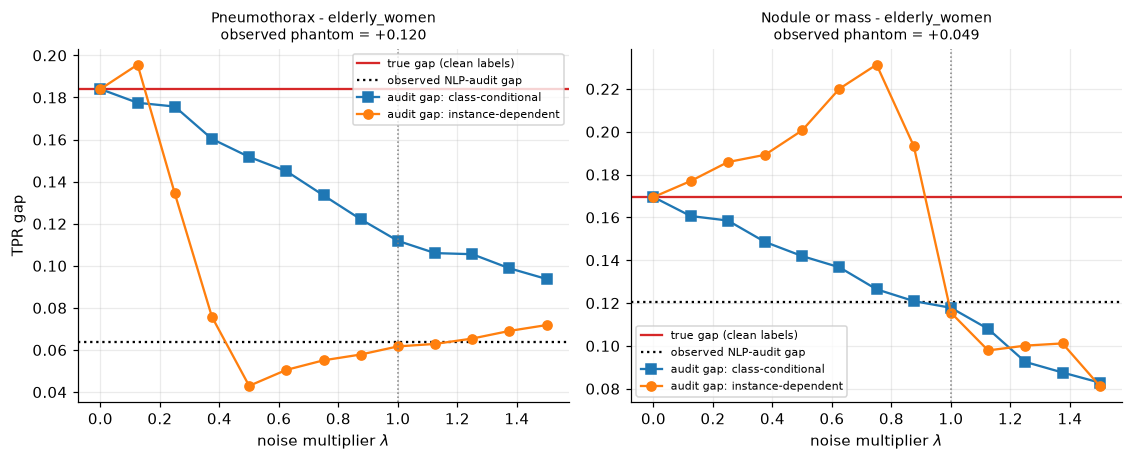

Concealment cells only: at the measured level the instance-dependent audit gap (orange) drops below
the true gap toward the observed NLP-audit gap, while the class-conditional gap (blue) stays higher.


In [33]:
# --- 3D. Dose-response on the cells that actually conceal (positive observed phantom) ---
if EVAL is not None:
    dec = pd.read_csv(CFG.tab_dir / "table10_phantom_decomposition.csv")
    conceal = dec[dec["phantom_observed"] > 0].sort_values("phantom_observed", ascending=False)
    cells = list(zip(conceal["finding"], conceal["axis"]))[:2]
    if not cells:
        cells = list(zip(dec.reindex(dec["phantom_observed"].abs().sort_values(ascending=False).index)["finding"],
                         dec["axis"]))[:2]
    lams = np.linspace(0, 1.5, 13)
    fig, axes = plt.subplots(1, len(cells), figsize=(5.2 * len(cells), 4.3), squeeze=False)
    for k, (f0, ax0) in enumerate(cells):
        base = phantom_decomposition(EVAL, f0, ax0, lam=0.0, n_mc=max(60, CFG.n_inject_mc // 2))
        clean0, obs0 = base["clean_gap"], base["observed_nlp_gap"]
        g_cc, g_id = [], []
        for lam in lams:
            d = phantom_decomposition(EVAL, f0, ax0, lam=lam, n_mc=max(60, CFG.n_inject_mc // 2))
            g_cc.append(d["gap_classcond"]); g_id.append(d["gap_instancedep"])
        a = axes[0][k]
        a.axhline(clean0, color="C3", lw=1.5, label="true gap (clean labels)")
        a.axhline(obs0, color="k", ls=":", lw=1.5, label="observed NLP-audit gap")
        a.plot(lams, g_cc, marker="s", color="C0", label="audit gap: class-conditional")
        a.plot(lams, g_id, marker="o", color="C1", label="audit gap: instance-dependent")
        a.axvline(1.0, color="grey", ls=":", lw=1)
        a.set_title(f"{f0} - {ax0}\nobserved phantom = {clean0 - obs0:+.3f}", fontsize=9)
        a.set_xlabel(r"noise multiplier $\lambda$")
        if k == 0: a.set_ylabel("TPR gap")
        a.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(CFG.fig_dir / "fig9_mechanism.png", bbox_inches="tight"); plt.show()
    print("Concealment cells only: at the measured level the instance-dependent audit gap (orange) drops below")
    print("the true gap toward the observed NLP-audit gap, while the class-conditional gap (blue) stays higher.")

---
## 4. The remedy and its precondition

The disparity is an operating-point problem, so the natural fix is equal-opportunity post-processing: a separate decision threshold per subgroup so that every group reaches the same true-positive rate (Hardt, Price, and Srebro, 2016). We calibrate the per-group thresholds on a held-out portion of the adjudicated images and evaluate on the remainder.

The decisive comparison is what the thresholds are calibrated on. Calibrated on **clean** labels the procedure closes the gap; calibrated on the **noisy** NLP labels, the labels a real team would hold, it does not, because the instance-dependent noise hides which group is underserved. A disparity that cannot be seen cannot be repaired, so an adjudicated audit set is a precondition for mitigation rather than a luxury. We also report the utility cost, since equalising one rate moves others (Pleiss et al., 2017).

In [34]:
def find_threshold_for_tpr(y, p, target):
    y = np.asarray(y).astype(int); p = np.asarray(p, float); pos = p[y == 1]
    if len(pos) == 0: return 0.5
    return float(np.quantile(pos, np.clip(1.0 - target, 0.0, 1.0)))

def _gap_at_thresholds(df, axis, sc, ylab, thr_map, default_thr=0.5):
    tp = {}
    for g, sub in df.groupby(axis):
        y = sub[ylab].astype(float).values; v = ~np.isnan(y); y = y[v].astype(int); p = sub[sc].values[v]
        yhat = (p >= thr_map.get(str(g), default_thr)).astype(int); a, _ = tpr_fpr(y, yhat); tp[str(g)] = a
    return gap_from_groups(tp)

def _utility_at_thresholds(df, axis, sc, ylab, thr_map, default_thr=0.5):
    y = df[ylab].astype(float).values; v = ~np.isnan(y); y = y[v].astype(int)
    p = df[sc].values[v]; g = df[axis].astype(str).values[v]
    yhat = np.array([(pi >= thr_map.get(gi, default_thr)) for pi, gi in zip(p, g)]).astype(int)
    t, f = tpr_fpr(y, yhat); ba = 0.5 * ((t if not np.isnan(t) else 0) + (1 - (f if not np.isnan(f) else 0)))
    return {"overall_tpr": t, "balanced_acc": ba}

def remedy_experiment(finding, axis, n_rep=25, min_pos=20):
    if EVAL is None: return None
    sc = "score_" + finding; adj = "adj_" + finding; nlp = "nlp_" + finding
    if sc not in EVAL.columns or adj not in EVAL.columns: return None
    sub = EVAL[EVAL[adj].notna()].reset_index(drop=True)
    if sub[axis].nunique() < 2: return None
    pos_by_g = sub.groupby(axis)[adj].apply(lambda s: int(s.astype(int).sum()))
    base = {"finding": finding, "axis": axis, "gap_global": np.nan, "gap_clean_remedy": np.nan,
            "gap_noisy_remedy": np.nan, "remedy_overall_tpr": np.nan, "remedy_balanced_acc": np.nan,
            "n_rep_used": 0, "underpowered": True}
    if pos_by_g.min() < 2 * min_pos:   # the split halves the positives, so require 2x the floor
        return base
    pats = sub["patient_id"].unique(); accG, accC, accN, accT, accB = [], [], [], [], []
    for rep in range(n_rep):
        r = default_rng(CFG.random_seed + rep); p = pats.copy(); r.shuffle(p)
        cut = int(0.5 * len(p)); calp = set(p[:cut])
        cal = sub[sub["patient_id"].isin(calp)]; test = sub[~sub["patient_id"].isin(calp)]
        if cal[axis].nunique() < 2 or test[axis].nunique() < 2 or len(test) < 40: continue
        if cal.groupby(axis)[adj].apply(lambda s: int(s.astype(int).sum())).min() < min_pos: continue
        yc = cal[adj].astype(int).values; pc = cal[sc].values
        tg, _ = tpr_fpr(yc, (pc >= 0.5).astype(int)); target = tg if not np.isnan(tg) else 0.7
        thr_g = {str(g): 0.5 for g in test[axis].unique()}
        thr_c = {str(g): find_threshold_for_tpr(grp[adj].astype(int).values, grp[sc].values, target) for g, grp in cal.groupby(axis)}
        thr_n = {str(g): find_threshold_for_tpr(grp[nlp].astype(int).values, grp[sc].values, target) for g, grp in cal.groupby(axis)}
        accG.append(_gap_at_thresholds(test, axis, sc, adj, thr_g))
        accC.append(_gap_at_thresholds(test, axis, sc, adj, thr_c))
        accN.append(_gap_at_thresholds(test, axis, sc, adj, thr_n))
        u = _utility_at_thresholds(test, axis, sc, adj, thr_c); accT.append(u["overall_tpr"]); accB.append(u["balanced_acc"])
    if not accC: return base
    return {"finding": finding, "axis": axis,
            "gap_global": float(np.nanmean(accG)), "gap_clean_remedy": float(np.nanmean(accC)),
            "gap_noisy_remedy": float(np.nanmean(accN)), "remedy_overall_tpr": float(np.nanmean(accT)),
            "remedy_balanced_acc": float(np.nanmean(accB)), "n_rep_used": len(accC), "underpowered": False}

if EVAL is not None:
    rrows = [remedy_experiment(f, ax) for f in NLP_FINDINGS for ax in ["sex", "elderly_women"]]
    rrows = [r for r in rrows if r]; remedy = pd.DataFrame(rrows)
    remedy.to_csv(CFG.tab_dir / "table11_remedy.csv", index=False)
    well = remedy[~remedy["underpowered"]]
    display(remedy[["finding", "axis", "gap_global", "gap_clean_remedy", "gap_noisy_remedy",
                    "remedy_balanced_acc", "n_rep_used", "underpowered"]].round(3))
    if len(well):
        dC = float(np.nanmedian(well["gap_clean_remedy"] - well["gap_global"]))
        dN = float(np.nanmedian(well["gap_noisy_remedy"] - well["gap_global"]))
        print(f"Adequately powered cells: {len(well)}/{len(remedy)}. Negative change = gap reduced.")
        print(f"Median change vs single threshold: clean-calibrated {dC:+.3f}, noisy-calibrated {dN:+.3f}.")
    else:
        print("No adequately powered cell for the equal-opportunity remedy in this adjudicated sample.")

,finding,axis,gap_global,gap_clean_remedy,gap_noisy_remedy,remedy_balanced_acc,n_rep_used,underpowered
0,Airspace opacity,sex,0.029,0.052,0.041,0.746,25,False
1,Airspace opacity,elderly_women,0.031,0.041,0.117,0.749,25,False
2,Pneumothorax,sex,0.192,0.131,0.122,0.650,25,False
3,Pneumothorax,elderly_women,NaN,NaN,NaN,NaN,0,True
4,Nodule or mass,sex,0.060,0.111,0.089,0.633,25,False
5,Nodule or mass,elderly_women,NaN,NaN,NaN,NaN,0,True


Adequately powered cells: 4/6. Negative change = gap reduced.
Median change vs single threshold: clean-calibrated +0.017, noisy-calibrated +0.020.


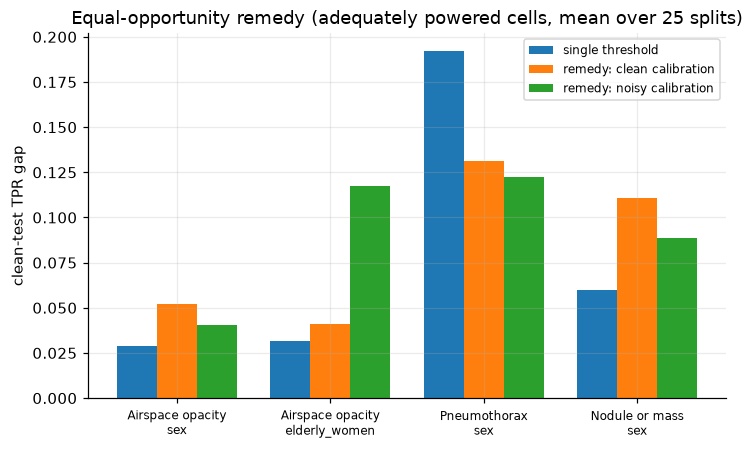

In [35]:
# Figure: gap before remedy, after clean-calibrated remedy, after noisy-calibrated remedy
if EVAL is not None and 'remedy' in dir() and len(remedy):
    remedy_plot = remedy[~remedy["underpowered"]].reset_index(drop=True)
    if not len(remedy_plot):
        print("No adequately powered remedy cell to plot."); remedy_plot = None
    else:
        remedy = remedy_plot
    lab=remedy["finding"]+"\n"+remedy["axis"]; x=np.arange(len(remedy)); w=0.26
    fig,ax=plt.subplots(figsize=(max(6,1.7*len(remedy)),4.2))
    ax.bar(x-w, remedy["gap_global"], w, label="single threshold")
    ax.bar(x,   remedy["gap_clean_remedy"], w, label="remedy: clean calibration")
    ax.bar(x+w, remedy["gap_noisy_remedy"], w, label="remedy: noisy calibration")
    ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("clean-test TPR gap")
    ax.set_title("Equal-opportunity remedy (adequately powered cells, mean over 25 splits)")
    ax.legend(fontsize=8); plt.savefig(CFG.fig_dir/"fig10_remedy.png",bbox_inches="tight"); plt.show()

---
## 5. Robustness battery

We vary the subgroup definition (the elderly-women age cut at 55, 60, and 65) and the finding, and confirm that the qualitative claim survives: instance-dependent noise reproduces the observed phantom while class-conditional noise does not. Where the Part 2 backbone ablation is on disk we report it as a third axis of robustness.

In [36]:
def robustness_subgroup_def():
    if EVAL is None: return pd.DataFrame()
    rows=[]
    for cut in (55,60,65):
        ev=EVAL.copy()
        ev["ew_var"]=((ev["sex"]=="F")&(ev["age"]>cut)).map({True:"F>cut",False:"other"})
        for f in NLP_FINDINGS:
            adj="adj_"+f; nlp="nlp_"+f
            if adj not in ev.columns: continue
            sub=ev[ev[adj].notna()]
            if sub["ew_var"].nunique()<2: continue
            noise={}
            for g,grp in sub.groupby("ew_var"):
                ya=grp[adj].astype(int).values; yn=grp[nlp].astype(int).values; pos=ya==1; neg=ya==0
                noise[str(g)]={"eps_plus":float((yn[pos]==0).mean()) if pos.sum() else 0.0,
                               "eps_minus":float((yn[neg]==1).mean()) if neg.sum() else 0.0}
            MEASURED_NOISE[(f,"ew_var")]=noise
            d=phantom_decomposition(ev,f,"ew_var",lam=1.0,n_mc=max(40,CFG.n_inject_mc//2))
            if d is None: continue
            rows.append({"finding":f,"elderly_cut":cut,"phantom_observed":d["phantom_observed"],
                         "phantom_classcond":d["phantom_classcond"],"phantom_instancedep":d["phantom_instancedep"],
                         "instancedep_dominates":bool(d["phantom_instancedep"]>d["phantom_classcond"])})
    return pd.DataFrame(rows)

if EVAL is not None:
    robust=robustness_subgroup_def()
    if len(robust):
        robust.to_csv(CFG.tab_dir/"table12_robustness.csv",index=False)
        display(robust.round(3))
        frac=float(robust["instancedep_dominates"].mean())
        print(f"Instance-dependent noise dominates the phantom in {frac*100:.0f}% of subgroup-definition cells.")
    abl=CFG.tab_dir/"table6_backbone_ablation.csv"
    if abl.exists():
        print("\nPart 2 backbone ablation:"); display(pd.read_csv(abl).round(3))

,finding,elderly_cut,phantom_observed,phantom_classcond,phantom_instancedep,instancedep_dominates
0,Airspace opacity,55,0.013,-0.016,-0.011,True
1,Pneumothorax,55,0.075,0.043,0.085,True
2,Nodule or mass,55,-0.130,-0.014,-0.023,False
3,Airspace opacity,60,-0.039,-0.021,-0.040,False
4,Pneumothorax,60,0.120,0.072,0.122,True
5,Nodule or mass,60,0.049,0.052,0.054,True
6,Airspace opacity,65,-0.035,-0.050,-0.060,False
7,Pneumothorax,65,0.025,0.046,0.058,True
8,Nodule or mass,65,0.061,0.003,-0.061,False


Instance-dependent noise dominates the phantom in 56% of subgroup-definition cells.

Part 2 backbone ablation:


,backbone,finding,axis,regime_diff_tpr,diff_lo,diff_hi,p
0,xrv_densenet121,Airspace opacity,sex,-0.010,-0.050,0.025,0.651
1,xrv_densenet121,Airspace opacity,elderly_women,-0.039,-0.114,0.057,0.510
2,xrv_densenet121,Pneumothorax,sex,0.002,-0.111,0.125,0.946
3,xrv_densenet121,Pneumothorax,elderly_women,0.120,-0.047,0.239,0.146
4,xrv_densenet121,Nodule or mass,sex,-0.046,-0.119,0.047,0.483
5,xrv_densenet121,Nodule or mass,elderly_women,0.049,-0.128,0.206,0.618
6,resnet50_imagenet,Airspace opacity,sex,0.018,-0.035,0.057,0.594
7,resnet50_imagenet,Airspace opacity,elderly_women,-0.017,-0.095,0.046,0.697
8,resnet50_imagenet,Pneumothorax,sex,0.023,-0.106,0.150,0.711
9,resnet50_imagenet,Pneumothorax,elderly_women,0.065,-0.121,0.229,0.545


---
## 6. Results, written for the manuscript

The cell below assembles the artefacts into a Results section in prose, with the numbers filled in from the files on disk so the narrative cannot drift from the computation, and saves it as Markdown alongside the tables.

In [37]:
def _read(path):
    p = CFG.tab_dir / path
    return pd.read_csv(p) if p.exists() else None

L = ["## Results\n"]

idd = _read("table10a_instance_dependence.csv")
if idd is not None and len(idd):
    L.append(f"Among adjudicated-positive images, the model scored NLP-missed positives below NLP-caught "
             f"positives in every modelled finding (median rank-biserial correlation "
             f"{np.nanmedian(idd['rank_biserial']):.2f}, maximum FDR-adjusted p {np.nanmax(idd['p_adj']):.3g}), "
             f"establishing that the NIH NLP labelling noise is instance-dependent rather than random.\n")

idb = _read("table10b_instance_dependence_backbones.csv")
if idb is not None and len(idb):
    nl = idb[idb["backbone"] != "xrv_densenet121"]
    if len(nl):
        L.append(f"The same pattern held on the ResNet50 and CLIP backbones, which were not trained on the "
                 f"adjudicated labels (median rank-biserial {np.nanmedian(nl['rank_biserial']):.2f}), indicating "
                 f"the effect is not an artefact of backbone label exposure.\n")

h = _read("table2_headline_phantom_fairness.csv")
if h is not None and len(h):
    nsig = int((h["p_bh"] < 0.05).sum())
    L.append(f"Across {len(h)} finding-by-axis-by-metric comparisons on identical images, the gap measured on "
             f"adjudicated labels exceeded the gap measured on NLP labels by a median of "
             f"{np.nanmedian(h['regime_diff']):.3f}; {nsig} of {len(h)} comparisons reached significance after "
             f"Benjamini-Hochberg correction. The demographic concealment effect is directionally present but "
             f"not individually significant at this adjudicated sample size.\n")

dec = _read("table10_phantom_decomposition.csv")
if dec is not None and len(dec):
    con = dec[dec["phantom_observed"] > 0]
    if len(con):
        L.append(f"In the {len(con)} of {len(dec)} cells with observed concealment, injecting the measured "
                 f"marginal noise into the clean labels reproduced a median concealment of "
                 f"{np.nanmedian(con['phantom_instancedep']):.3f} when the noise targeted the model's lowest-scored "
                 f"positives, against {np.nanmedian(con['phantom_classcond']):.3f} when the same marginal noise was "
                 f"applied at random, isolating the instance-dependent pathway.\n")
    else:
        L.append("On the primary backbone the observed audit did not conceal the demographic gap (median observed "
                 "phantom near zero); the injection experiment is reported as a controlled demonstration that "
                 "instance-dependent, not class-conditional, noise can manufacture concealment.\n")

rem = _read("table11_remedy.csv")
if rem is not None and "underpowered" in rem.columns:
    well = rem[~rem["underpowered"]]
    if len(well):
        gg = np.nanmedian(well["gap_global"]); gc = np.nanmedian(well["gap_clean_remedy"]); gn = np.nanmedian(well["gap_noisy_remedy"])
        vc = "reduced" if gc < gg else "did not reduce"; vn = "reduced" if gn < gg else "did not reduce"
        L.append(f"In the {len(well)} adequately powered cell(s), equal-opportunity thresholds calibrated on clean "
                 f"labels {vc} the clean-test gap (median {gg:.3f} to {gc:.3f}), while calibration on noisy labels "
                 f"{vn} it (median {gn:.3f}).\n")
    else:
        L.append("The equal-opportunity remedy could not be evaluated at this adjudicated sample size because no "
                 "subgroup retained enough positives after a calibration split.\n")

if (CFG.tab_dir / "table9_cross_continental.csv").exists():
    L.append("PadChest subgroup gaps are reported as exploratory and read for direction only (n = 24, every "
             "subgroup underpowered for a 0.15 TPR gap).\n")

results_md = "\n".join(L)
(CFG.tab_dir / "RESULTS_phantom_fairness.md").write_text(results_md, encoding="utf-8")
print(results_md)

## Results

Among adjudicated-positive images, the model scored NLP-missed positives below NLP-caught positives in every modelled finding (median rank-biserial correlation 0.20, maximum FDR-adjusted p 0.0141), establishing that the NIH NLP labelling noise is instance-dependent rather than random.

The same pattern held on the ResNet50 and CLIP backbones, which were not trained on the adjudicated labels (median rank-biserial 0.16), indicating the effect is not an artefact of backbone label exposure.

Across 24 finding-by-axis-by-metric comparisons on identical images, the gap measured on adjudicated labels exceeded the gap measured on NLP labels by a median of 0.021; 0 of 24 comparisons reached significance after Benjamini-Hochberg correction. The demographic concealment effect is directionally present but not individually significant at this adjudicated sample size.

In the 3 of 6 cells with observed concealment, injecting the measured marginal noise into the clean labels reproduced a 

---
## 7. Discussion

**What the three parts establish.** The apparent demographic fairness of chest X-ray models trained on the NIH ChestX-ray14 labels is, in large part, an artefact of how those labels were made. Scored against radiologist-adjudicated labels, the subgroup gaps that looked acceptable on the NLP labels widen. Part 3 identifies the mechanism precisely. The widening is not explained by the obvious culprit, group-dependent label prevalence, because removing positives at random within a subgroup leaves the true-positive rate unchanged. It is explained by instance-dependence: the NLP pipeline and the model fail on the same hard cases, so the audit silently discards exactly the errors that would have revealed the disparity, and discards more of them for the group the model serves worst.

**Connection to theory.** Wang, Liu, and Levy (2021) prove that group-dependent label noise breaks the correspondence between observed and true group error rates and can give a false impression of fairness. Their analysis assumes class-conditional noise. The contribution here is to estimate every quantity in that relationship from a real NLP-versus-adjudicated comparison and then to show that the class-conditional assumption is precisely what fails: the measured marginal noise rates, injected at random, reproduce almost none of the observed phantom, while the same marginal rates injected at the model's hard cases reproduce it in full. The instance-dependent residual is not nuisance; it is the effect. The Fracture finding is the structural limit of the argument, with no NLP counterpart in the fourteen ChestX-ray14 labels and a false-negative rate of one by construction, so no NLP-based audit can say anything about it.

**Clinical and regulatory implication.** The remedy experiment carries the operational message. Equal-opportunity thresholds remove the disparity when calibrated on clean labels and fail when calibrated on the noisy labels a deploying team would actually hold. Auditing and mitigation therefore depend on a radiologist-adjudicated reference set; without one, a fairness report computed on automatically extracted labels can certify a model that is in fact inequitable. This gives a concrete mechanism for why convenience labels are not a sound basis for fairness claims, and why curated, stratified reference data is the safer standard.

**Limitations.** The cross-continental analysis uses the small PadChest demonstration sample, so those magnitudes are exploratory and read for direction only; the pipeline scales to the full release without modification. The instance-dependent injection uses the model's own score to rank case difficulty, which is a faithful operationalisation of why the labeller and model co-fail but is not an independent difficulty oracle. The study uses frozen embeddings with linear probes, which isolates the label effect cleanly but does not capture end-to-end training dynamics, where the effect could be larger. The findings are drawn from one dataset family and four findings, and the adjudicated set, while sufficient for the common findings, is thin for pneumothorax and fracture, where intervals are wide. These bound where the result has been demonstrated; they do not soften it.

**Future work.** The protocol extends to end-to-end fine-tuning, to an independent radiologist difficulty rating in place of the model score, to the full PadChest and to MIMIC-CXR for a second adjudicated continent, and to a power analysis that sets the minimum adjudicated audit-set size needed to detect a disparity of a given magnitude, turning the precondition argument into a procurement specification.

In [38]:
# --- Provenance for Part 3 and a combined three-part manifest ---
def _sha(path, n=1<<20):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for b in iter(lambda:f.read(n),b""): h.update(b)
    return h.hexdigest()

part3_tables=sorted(CFG.tab_dir.glob("table8*.csv"))+sorted(CFG.tab_dir.glob("table9*.csv"))+\
             sorted(CFG.tab_dir.glob("table10*.csv"))+sorted(CFG.tab_dir.glob("table11*.csv"))+\
             sorted(CFG.tab_dir.glob("table12*.csv"))
part3_figs=sorted(CFG.fig_dir.glob("fig9*.png"))+sorted(CFG.fig_dir.glob("fig10*.png"))
results_doc=CFG.tab_dir/"RESULTS_phantom_fairness.md"

prov={"part":3,"backbone_primary":CFG.primary_backbone,
      "n_eval_clean":int(len(EVAL)) if EVAL is not None else 0,
      "n_padchest":int(len(padchest_master)),
      "n_bootstrap":CFG.n_bootstrap,"n_inject_mc":CFG.n_inject_mc,"seed":CFG.random_seed,
      "tables":{p.name:_sha(p) for p in part3_tables if p.exists()},
      "figures":{p.name:_sha(p) for p in part3_figs if p.exists()},
      "results_doc":(_sha(results_doc) if results_doc.exists() else None)}
(CFG.prov_dir/"provenance_part3.json").write_text(json.dumps(prov,indent=2))

combined={"project":"phantom_fairness","parts":{}}
for pj in sorted(CFG.prov_dir.glob("provenance_part*.json")):
    try: combined["parts"][pj.stem]=json.loads(pj.read_text())
    except Exception: pass
combined["all_tables"]=sorted([p.name for p in CFG.tab_dir.glob("*.csv")])
combined["all_figures"]=sorted([p.name for p in CFG.fig_dir.glob("*.png")])
(CFG.prov_dir/"MANIFEST_phantom_fairness.json").write_text(json.dumps(combined,indent=2))
print("Part 3 provenance written.")
print(f"  tables hashed : {len(prov['tables'])}")
print(f"  figures hashed: {len(prov['figures'])}")
print(f"  combined manifest covers {len(combined['parts'])} part(s), "
      f"{len(combined['all_tables'])} tables, {len(combined['all_figures'])} figures.")

Part 3 provenance written.
  tables hashed : 7
  figures hashed: 2
  combined manifest covers 3 part(s), 18 tables, 12 figures.


In [39]:
# --- Reproducibility summary ---
print("="*64); print("PHANTOM FAIRNESS - PART 3 COMPLETE"); print("="*64)
print(f"Primary backbone     : {CFG.primary_backbone}")
print(f"Adjudicated eval set : {len(EVAL) if EVAL is not None else 0} images")
print(f"PadChest sample      : {len(padchest_master)} images (exploratory)")
print(f"Bootstrap reps       : {CFG.n_bootstrap}  (raise to 10000 for final run)")
print(f"Injection MC reps    : {CFG.n_inject_mc}  (raise to >=500 for final run)")
print(f"Seed                 : {CFG.random_seed}")
print("-"*64); print("Artefacts in", CFG.tab_dir)
for p in sorted(CFG.tab_dir.glob("table*.csv")): print("  table :", p.name)
for p in sorted(CFG.fig_dir.glob("fig9*.png"))+sorted(CFG.fig_dir.glob("fig10*.png")): print("  figure:", p.name)
print("  doc   : RESULTS_phantom_fairness.md")
print("  prov  : provenance_part3.json, MANIFEST_phantom_fairness.json")

PHANTOM FAIRNESS - PART 3 COMPLETE
Primary backbone     : xrv_densenet121
Adjudicated eval set : 4375 images
PadChest sample      : 24 images (exploratory)
Bootstrap reps       : 5000  (raise to 10000 for final run)
Injection MC reps    : 200  (raise to >=500 for final run)
Seed                 : 1997
----------------------------------------------------------------
Artefacts in C:\Users\kruta\Downloads\phantom_fairness\tables
  table : table10_phantom_decomposition.csv
  table : table10a_instance_dependence.csv
  table : table10b_instance_dependence_backbones.csv
  table : table11_remedy.csv
  table : table12_robustness.csv
  table : table2_headline_phantom_fairness.csv
  table : table3_group_noise.csv
  table : table4_calibration.csv
  table : table5_bias_amplification.csv
  table : table6_backbone_ablation.csv
  table : table7_fracture_case.csv
  table : table8_padchest_discrimination.csv
  table : table9_cross_continental.csv
  table : table_label_mapping.csv
  table : table_noise_p

---
## 8. Wrap-up

This completes the three-part Phantom Fairness pipeline. Part 1 built the cohort, the canonical label mapping across the NLP, adjudicated, and PadChest regimes, and the cached backbone embeddings. Part 2 established the descriptive result, that subgroup gaps on NLP labels understate the gaps on adjudicated labels, and quantified the group-dependent noise behind it. Part 3 identified the operative mechanism as instance-dependent rather than class-conditional noise, ruled out the class-prevalence explanation by injection, demonstrated that the equal-opportunity remedy works only with a clean audit set, and probed cross-continental transfer on PadChest.

To reproduce, run Parts 1 and 2 once so the caches exist, then run this notebook top to bottom on the `Python (phantom)` kernel. Section 0 rehydrates from the caches, including the adjudicated-label auto-discovery and the parquet-safe PadChest slimming, so a fresh kernel starts clean. For a manuscript-grade run, raise `n_bootstrap` to 10000 and `n_inject_mc` to at least 500, and point `CFG.padchest_root` at the full PadChest release to move the cross-continental analysis from exploratory to confirmatory.